<a href="https://colab.research.google.com/github/iav2002/AppliedDeepLearning/blob/main/Part2_Baselines_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applied Deep Learning, Part 2: Notebook 3
## Baselines

First Colab notebook. Establishes the patterns used in notebooks 4 through 8.

What we build here
1. A regression baseline (predicts age as a real number)
2. A classification baseline (predicts age category)

Both use the same architecture so any later variation can be compared against a known reference. Nothing fancy in this notebook, the point is to lock in the train loop, dataset class, and evaluation conventions.

In [1]:
# mount drive so we can pull the dataset and CSVs
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# copy zip + csvs to local colab disk for fast reads during training
# /content is on SSD, /content/drive is a slow remote mount
!cp "/content/drive/MyDrive/Colab Notebooks/AppliedDL/face_age.zip" /content/
!cp -r "/content/drive/MyDrive/Colab Notebooks/AppliedDL/data_splits" /content/

# unzip the dataset
!unzip -q /content/face_age.zip -d /content/

# quick sanity check
!ls /content/face_age | head
!ls /content/data_splits

001
002
003
004
005
006
007
008
009
010
block1.csv  block2.csv	test.csv  train.csv  val.csv


## 2. Imports and dataset class

Standard PyTorch setup. We define one Dataset class that works for both regression and classification, the only difference is which label column the DataLoader returns.

In [3]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from pathlib import Path

# device, use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("gpu:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

device: cuda
gpu: NVIDIA L4


## 3. FaceAge dataset class

Reads from one of our CSVs, returns image plus label. The `task` argument switches between regression (returns float age) and classification (returns category index).

Path handling note, the CSVs store relative paths like `face_age/001/3791.png`. We prepend `/content/` so they resolve correctly on Colab.

In [4]:
# category names in fixed order, matches what was decided in EDA
CATEGORIES = ["infant", "child", "teen", "youth", "mid", "mature", "senior"]
CAT_TO_IDX = {c: i for i, c in enumerate(CATEGORIES)}


class FaceAgeDataset(Dataset):
    def __init__(self, csv_path, task, transform=None):
        # task is either "regression" or "classification"
        self.df = pd.read_csv(csv_path)
        self.task = task
        self.transform = transform
        # build full paths once at init so __getitem__ is fast
        self.paths = ["/content/" + p for p in self.df["path"]]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # load image as RGB (already is, but defensive)
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        if self.task == "regression":
            # return age as float tensor for MSE loss
            label = torch.tensor(self.df.iloc[idx]["age"], dtype=torch.float32)
        else:
            # return category index as long tensor for CrossEntropyLoss
            cat = self.df.iloc[idx]["age_category"]
            label = torch.tensor(CAT_TO_IDX[cat], dtype=torch.long)

        return img, label

## 4. Transforms and dataloaders

Standard ImageNet normalization stats since faces aren't wildly different in distribution. For the baseline we keep transforms minimal, just ToTensor + Normalize. Interesting experiments will be in the future


In [5]:
# simple transform pipeline, no augmentation for baseline
transform = transforms.Compose([
    transforms.ToTensor(),                              # PIL -> tensor, scales to [0,1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406],    # standard ImageNet stats
                         std=[0.229, 0.224, 0.225]),
])

# build datasets, one per split, one per task
train_ds_reg = FaceAgeDataset("/content/data_splits/train.csv", "regression", transform)
val_ds_reg   = FaceAgeDataset("/content/data_splits/val.csv",   "regression", transform)

train_ds_cls = FaceAgeDataset("/content/data_splits/train.csv", "classification", transform)
val_ds_cls   = FaceAgeDataset("/content/data_splits/val.csv",   "classification", transform)

print(f"train: {len(train_ds_reg)}    val: {len(val_ds_reg)}")

# quick check, look at one sample
img, lbl = train_ds_reg[0]
print(f"\nsample image shape: {img.shape}    sample label: {lbl}")

train: 7320    val: 1464

sample image shape: torch.Size([3, 200, 200])    sample label: 2.0


## 5. Baseline CNN

Simple CNN to use as a reference point. Three conv blocks followed by two fully connected layers. Same architecture for both regression and classification, only the final layer changes (1 output for regression, 7 for classification).

Design choices kept boring on purpose. ReLU activations, 3x3 kernels, max pooling, no batch norm. We can vary all of these later.

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_outputs):
        # num_outputs is 1 for regression, 7 for classification
        super().__init__()

        # conv block 1, 3 -> 32 channels, image goes from 200 to 100
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)

        # conv block 2, 32 -> 64 channels, 100 to 50
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

        # conv block 3, 64 -> 128 channels, 50 to 25
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(2)

        # flatten and feed into fully connected layers
        # after pool3 we have 128 x 25 x 25 = 80000 features
        self.fc1 = nn.Linear(128 * 25 * 25, 128)
        self.fc2 = nn.Linear(128, num_outputs)

        self.relu = nn.ReLU()

    def forward(self, x):
        # conv blocks with relu and pooling
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))

        # flatten for fully connected
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# quick test, build the model and run a dummy input through it
model = BaselineCNN(num_outputs=1).to(device)
dummy = torch.randn(2, 3, 200, 200).to(device)
out = model(dummy)
print(f"output shape: {out.shape}")
print(f"total parameters: {sum(p.numel() for p in model.parameters()):,}")

output shape: torch.Size([2, 1])
total parameters: 10,333,505


## 6. DataLoaders

Wrap the datasets in DataLoaders. Batch size 64 is a safe default for an L4. num_workers parallelises image decoding so the GPU isn't waiting on the CPU.

In [7]:
BATCH_SIZE = 64

# regression loaders
train_loader_reg = DataLoader(train_ds_reg, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
val_loader_reg   = DataLoader(val_ds_reg,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

# classification loaders
train_loader_cls = DataLoader(train_ds_cls, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=4, pin_memory=True, persistent_workers=True)
val_loader_cls   = DataLoader(val_ds_cls,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=4, pin_memory=True, persistent_workers=True)

# quick check, pull one batch and look at shapes
imgs, lbls = next(iter(train_loader_reg))
print(f"batch images: {imgs.shape}    batch labels: {lbls.shape}")

batch images: torch.Size([64, 3, 200, 200])    batch labels: torch.Size([64])


## 7. Train and eval functions

Generic functions that work for both tasks. The caller passes in the model, loss function, and loaders. We track train loss, val loss, and a task-specific metric (MAE for regression, accuracy for classification).

In [8]:
def train_one_epoch(model, loader, loss_fn, optimizer):
    # set to training mode, enables dropout/batchnorm if present
    model.train()
    total_loss = 0
    n_samples = 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        # forward pass
        out = model(imgs)
        # for regression, model outputs shape [B,1], squeeze to match labels [B]
        if out.shape[-1] == 1:
            out = out.squeeze(-1)
        loss = loss_fn(out, lbls)

        # backward and update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # track running loss, weighted by batch size since last batch may be smaller
        total_loss += loss.item() * imgs.size(0)
        n_samples += imgs.size(0)

    return total_loss / n_samples


def evaluate(model, loader, loss_fn, task):
    # set to eval mode, disables dropout
    model.eval()
    total_loss = 0
    n_samples = 0
    correct = 0
    abs_error_sum = 0

    # no grad needed for eval, saves memory
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            if out.shape[-1] == 1:
                out = out.squeeze(-1)
            loss = loss_fn(out, lbls)

            total_loss += loss.item() * imgs.size(0)
            n_samples += imgs.size(0)

            if task == "regression":
                # MAE, more interpretable than MSE since it's in years
                abs_error_sum += (out - lbls).abs().sum().item()
            else:
                # accuracy, argmax over class logits
                preds = out.argmax(dim=1)
                correct += (preds == lbls).sum().item()

    avg_loss = total_loss / n_samples
    if task == "regression":
        metric = abs_error_sum / n_samples  # mean absolute error in years
    else:
        metric = correct / n_samples         # accuracy as fraction

    return avg_loss, metric

## 8. Regression baseline training

Up to 20 epochs with early stopping. If val MAE doesn't improve for 4 consecutive epochs we stop and keep the best weights.

Loss is MSE (standard for regression). MAE is tracked as a metric because it's more interpretable, an MAE of 5 means we're off by 5 years on average.

In [9]:
# fresh model for regression, single output
model_reg = BaselineCNN(num_outputs=1).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg.parameters(), lr=1e-3)

MAX_EPOCHS = 20
PATIENCE = 4  # how many epochs to wait without improvement before stopping

# history dicts so we can plot curves after
history_reg = {"train_loss": [], "val_loss": [], "val_mae": []}

best_mae = float("inf")
best_state = None
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model_reg, train_loader_reg, loss_fn, optimizer)
    val_loss, val_mae = evaluate(model_reg, val_loader_reg, loss_fn, "regression")

    history_reg["train_loss"].append(train_loss)
    history_reg["val_loss"].append(val_loss)
    history_reg["val_mae"].append(val_mae)

    # check for improvement
    if val_mae < best_mae:
        best_mae = val_mae
        # save weights by copying state dict, .state_dict() returns references not copies
        best_state = {k: v.clone() for k, v in model_reg.state_dict().items()}
        epochs_no_improve = 0
        marker = " (best)"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"epoch {epoch:2d}    train_loss {train_loss:7.2f}    val_loss {val_loss:7.2f}    val_mae {val_mae:5.2f}{marker}")

    # early stop
    if epochs_no_improve >= PATIENCE:
        print(f"\nstopping early, no improvement for {PATIENCE} epochs")
        break

# restore best weights so further use of the model is the best version
model_reg.load_state_dict(best_state)
print(f"\nbest val MAE: {best_mae:.2f} years")

epoch  1    train_loss  516.44    val_loss  393.52    val_mae 15.96 (best)
epoch  2    train_loss  243.10    val_loss  320.70    val_mae 12.35 (best)
epoch  3    train_loss  186.15    val_loss  181.33    val_mae  9.40 (best)
epoch  4    train_loss  157.85    val_loss  160.11    val_mae  9.24 (best)
epoch  5    train_loss  125.63    val_loss  134.94    val_mae  8.10 (best)
epoch  6    train_loss  106.57    val_loss  143.29    val_mae  8.17
epoch  7    train_loss  100.87    val_loss  113.97    val_mae  7.49 (best)
epoch  8    train_loss   76.96    val_loss  124.78    val_mae  7.59
epoch  9    train_loss   63.05    val_loss  101.68    val_mae  6.93 (best)
epoch 10    train_loss   55.77    val_loss  100.01    val_mae  7.14
epoch 11    train_loss   43.28    val_loss  100.78    val_mae  7.12
epoch 12    train_loss   38.77    val_loss   98.44    val_mae  6.85 (best)
epoch 13    train_loss   31.30    val_loss  120.24    val_mae  7.31
epoch 14    train_loss   24.41    val_loss   95.40    val_ma

## 9. Regression training curves

Visualise train loss vs val loss to confirm the overfitting story, plus val MAE so we can read the actual error in years.

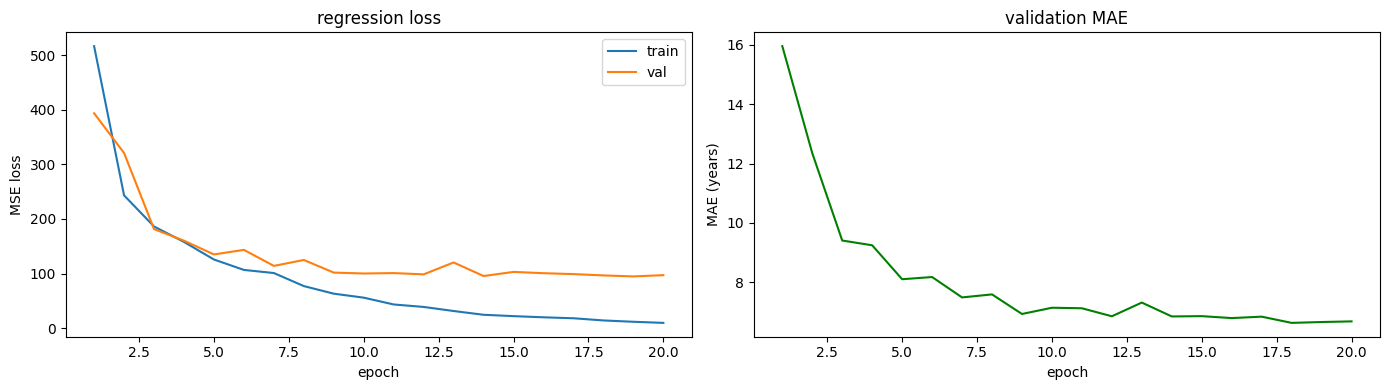

In [10]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_reg["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# left, train vs val loss
axes[0].plot(epochs, history_reg["train_loss"], label="train")
axes[0].plot(epochs, history_reg["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
axes[0].set_title("regression loss")
axes[0].legend()

# right, val MAE in years
axes[1].plot(epochs, history_reg["val_mae"], color="green")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MAE (years)")
axes[1].set_title("validation MAE")

plt.tight_layout()
plt.show()

## 10. Classification baseline

Same architecture, 7 outputs instead of 1. CrossEntropyLoss (which expects raw logits, so no softmax in the model). Up to 20 epochs with early stopping on val accuracy.

In [12]:
# fresh model for classification, 7 outputs (one per category)
model_cls = BaselineCNN(num_outputs=7).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cls.parameters(), lr=1e-3)

history_cls = {"train_loss": [], "val_loss": [], "val_acc": []}

best_acc = 0.0
best_state = None
epochs_no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model_cls, train_loader_cls, loss_fn, optimizer)
    val_loss, val_acc = evaluate(model_cls, val_loader_cls, loss_fn, "classification")

    history_cls["train_loss"].append(train_loss)
    history_cls["val_loss"].append(val_loss)
    history_cls["val_acc"].append(val_acc)

    # higher accuracy is better, opposite of MAE
    if val_acc > best_acc:
        best_acc = val_acc
        best_state = {k: v.clone() for k, v in model_cls.state_dict().items()}
        epochs_no_improve = 0
        marker = " (best)"
    else:
        epochs_no_improve += 1
        marker = ""

    print(f"epoch {epoch:2d}    train_loss {train_loss:.4f}    val_loss {val_loss:.4f}    val_acc {val_acc:.4f}{marker}")

    # if epochs_no_improve >= PATIENCE:
    #     print(f"\nstopping early, no improvement for {PATIENCE} epochs")
    #     break

model_cls.load_state_dict(best_state)
print(f"\nbest val accuracy: {best_acc:.4f} ({best_acc*100:.1f}%)")

epoch  1    train_loss 1.6334    val_loss 1.2483    val_acc 0.4959 (best)
epoch  2    train_loss 1.0990    val_loss 1.0840    val_acc 0.5485 (best)
epoch  3    train_loss 0.8998    val_loss 1.0170    val_acc 0.5867 (best)
epoch  4    train_loss 0.7396    val_loss 0.9897    val_acc 0.5997 (best)
epoch  5    train_loss 0.5598    val_loss 1.1097    val_acc 0.5943
epoch  6    train_loss 0.4083    val_loss 1.2042    val_acc 0.5956
epoch  7    train_loss 0.2516    val_loss 1.5337    val_acc 0.6086 (best)
epoch  8    train_loss 0.1503    val_loss 1.8346    val_acc 0.5908
epoch  9    train_loss 0.1129    val_loss 2.0646    val_acc 0.5881
epoch 10    train_loss 0.0783    val_loss 2.3796    val_acc 0.5956
epoch 11    train_loss 0.0585    val_loss 2.1995    val_acc 0.5990
epoch 12    train_loss 0.0381    val_loss 2.6325    val_acc 0.5949
epoch 13    train_loss 0.0312    val_loss 2.6475    val_acc 0.5915
epoch 14    train_loss 0.0243    val_loss 2.7065    val_acc 0.5922
epoch 15    train_loss 0.02

## 11. Classification training curves

Same visualisation as before. Loss curves on the left, accuracy on the right. The val_loss curve makes the overfitting story visually obvious.

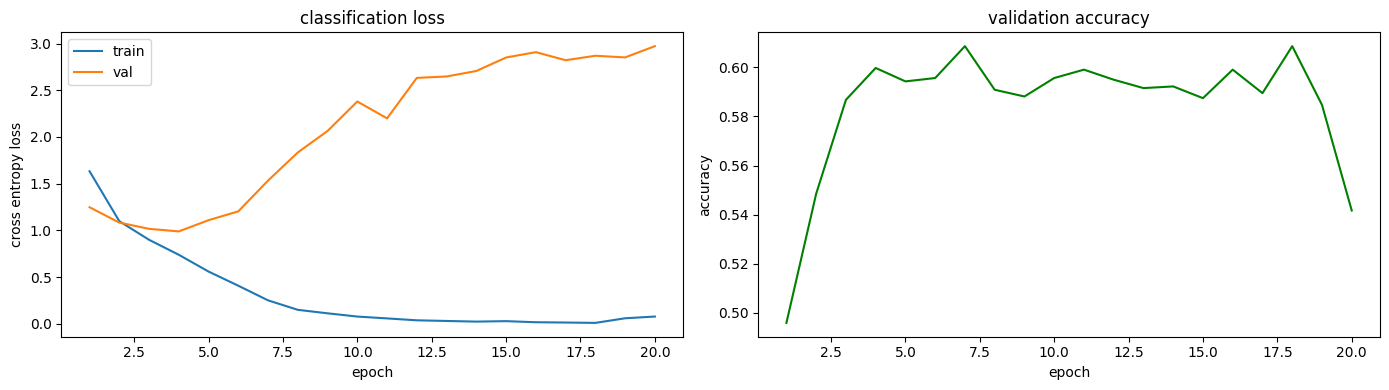

In [13]:
epochs = range(1, len(history_cls["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs, history_cls["train_loss"], label="train")
axes[0].plot(epochs, history_cls["val_loss"], label="val")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross entropy loss")
axes[0].set_title("classification loss")
axes[0].legend()

axes[1].plot(epochs, history_cls["val_acc"], color="green")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("accuracy")
axes[1].set_title("validation accuracy")

plt.tight_layout()
plt.show()

## 12. Save baseline weights

Saved to make future comparisons

In [14]:
# save to colab disk first, then copy to drive
import os
os.makedirs("/content/models", exist_ok=True)

# regression baseline
torch.save({
    "state_dict": model_reg.state_dict(),
    "task": "regression",
    "arch": "BaselineCNN",
    "img_size": 200,
    "channels": 3,
    "val_mae": best_mae,
}, "/content/models/regression_baseline.pt")

# classification baseline
torch.save({
    "state_dict": model_cls.state_dict(),
    "task": "classification",
    "arch": "BaselineCNN",
    "num_classes": 7,
    "categories": CATEGORIES,
    "img_size": 200,
    "channels": 3,
    "val_acc": best_acc,
}, "/content/models/classification_baseline.pt")

# mirror to drive so they survive colab session ending
!mkdir -p "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models"
!cp /content/models/*.pt "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/"

print("saved")
!ls -lh "/content/drive/MyDrive/Colab Notebooks/AppliedDL/models/"

saved
total 79M
-rw------- 1 root root 40M May 11 13:53 classification_baseline.pt
-rw------- 1 root root 40M May 11 13:53 regression_baseline.pt
